# Capstone Final Notebook — Responsible ML Audit on 2024 HMDA LAR Data

**Goal:** Build and audit a classification model that predicts HMDA `action_taken`.

**Label definition:**
- `action_taken` in **1 or 2** → `target_approved = 1`
- `action_taken` equal **3** → `target_approved = 0`
- Other `action_taken` values are filtered out.

This notebook uses `data/2024_lar.parquet` and follows a governance-first feature strategy:
exclude leakage, exclude protected attributes from training, retain protected attributes only for audit, train baseline/mitigated models, and answer the 5 capstone questions.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [3]:
import os
import urllib.request
import zipfile

# Paths
url = "https://files.ffiec.cfpb.gov/dynamic-data/2024/2024_lar.zip"
zip_path = "data/2024_lar.zip"
data = "data/2024_lar.txt"

# Create folder
os.makedirs("data", exist_ok=True)

# Download if needed
if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")
else:
    print("Zip already exists.")

# Unzip if needed
if not os.path.exists(data):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data/")
    print("Extraction complete.")
else:
    print("Text file already exists.")

# Verify
print("Files in data folder:", os.listdir("data"))

Zip already exists.
Text file already exists.
Files in data folder: ['2024_lar.zip', '2024_lar.txt']


In [4]:
import duckdb

file_path = "data/2024_lar.txt"

con = duckdb.connect()

In [5]:
con.execute("""

COPY (

    SELECT *

    FROM read_csv_auto('data/2024_lar.txt', delim='|')

) TO 'data/2024_lar.parquet' (FORMAT PARQUET);

""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 0. Install and import packages

In [6]:
!pip install -q duckdb scikit-learn matplotlib pandas numpy

In [7]:
import os, warnings
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, brier_score_loss, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Load HMDA Parquet with DuckDB

In [8]:
parquet_path = "data/2024_lar.parquet"

if not os.path.exists(parquet_path):
    raise FileNotFoundError(
        f"Could not find {parquet_path}. Please upload/generate data/2024_lar.parquet first."
    )

con = duckdb.connect()

row_count = con.execute(f'''
    SELECT COUNT(*) AS total_rows
    FROM '{parquet_path}'
''').df()

row_count

,total_rows
0,12259129


## 2. Check schema

In [9]:
schema_df = con.execute(f'''
    DESCRIBE SELECT * FROM '{parquet_path}'
''').df()

schema_df

,column_name,column_type,null,key,default,extra
0,activity_year,BIGINT,YES,None,None,None
1,lei,VARCHAR,YES,None,None,None
2,derived_msa_md,BIGINT,YES,None,None,None
3,state_code,VARCHAR,YES,None,None,None
4,county_code,VARCHAR,YES,None,None,None
...,...,...,...,...,...,...
94,ffiec_msa_md_median_family_income,BIGINT,YES,None,None,None
95,tract_to_msa_income_percentage,DOUBLE,YES,None,None,None
96,tract_owner_occupied_units,BIGINT,YES,None,None,None
97,tract_one_to_four_family_homes,BIGINT,YES,None,None,None


## 3. Governance-based feature strategy

We do **not** use every variable.

Excluded from training:
- `action_taken`: target.
- `denial_reason_1` to `denial_reason_4`: post-outcome / leakage.
- `aus_1` to `aus_5`, `purchaser_type`, `hoepa_status`, `rate_spread`: potentially post-process/post-decision.
- Race, sex, and ethnicity fields: protected attributes. Used only for fairness audit.
- ID-like variables such as `lei` and `census_tract`.

`tract_minority_population_percent` is included in the baseline as a proxy-risk feature and removed in a mitigation experiment.

In [10]:
protected_cols = ["derived_race", "derived_sex", "derived_ethnicity"]

base_feature_cols = [
    "loan_amount", "loan_type", "loan_purpose", "lien_status", "loan_term",
    "open_end_line_of_credit", "business_or_commercial_purpose", "reverse_mortgage",
    "income", "debt_to_income_ratio", "combined_loan_to_value_ratio", "property_value",
    "occupancy_type", "construction_method", "total_units",
    "applicant_credit_score_type", "co_applicant_credit_score_type",
    "tract_population", "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage", "tract_owner_occupied_units",
    "tract_one_to_four_family_homes", "tract_median_age_of_housing_units"
]

proxy_features = ["tract_minority_population_percent"]

feature_cols_baseline = base_feature_cols + proxy_features
feature_cols_mitigated = base_feature_cols.copy()

required_cols = ["action_taken"] + protected_cols + feature_cols_baseline

available_cols = set(schema_df["column_name"].tolist())
missing_cols = [c for c in required_cols if c not in available_cols]
print("Missing columns:" if missing_cols else "All required columns are available.", missing_cols)

All required columns are available. []


## 4. Load model sample

For Colab stability, this notebook samples records from `action_taken` values 1, 2, and 3.
Increase `sample_size` if you have more RAM.

In [11]:
sample_size = 300000
select_cols_sql = ",\n    ".join(required_cols)

df = con.execute(f'''
    SELECT {select_cols_sql}
    FROM '{parquet_path}'
    WHERE action_taken IN (1, 2, 3)
    USING SAMPLE {sample_size} ROWS
''').df()

df.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(199102, 28)

## 5. Create label

In [12]:
df["target_approved"] = np.where(df["action_taken"].isin([1, 2]), 1, 0).astype(int)

df["target_approved"].value_counts(dropna=False), df["target_approved"].value_counts(normalize=True)

(target_approved
 1    150481
 0     48621
 Name: count, dtype: int64,
 target_approved
 1    0.755799
 0    0.244201
 Name: proportion, dtype: float64)

## 6. Basic cleaning

In [13]:
numeric_cols = [
    "loan_amount", "income", "combined_loan_to_value_ratio", "property_value", "loan_term", "total_units",
    "tract_population", "ffiec_msa_md_median_family_income", "tract_to_msa_income_percentage",
    "tract_owner_occupied_units", "tract_one_to_four_family_homes", "tract_median_age_of_housing_units",
    "tract_minority_population_percent"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in df.columns:
    if col not in numeric_cols + ["target_approved", "action_taken"]:
        df[col] = df[col].astype("string")

df[required_cols + ["target_approved"]].head()

,action_taken,derived_race,derived_sex,derived_ethnicity,loan_amount,loan_type,loan_purpose,lien_status,loan_term,open_end_line_of_credit,business_or_commercial_purpose,reverse_mortgage,income,debt_to_income_ratio,combined_loan_to_value_ratio,property_value,occupancy_type,construction_method,total_units,applicant_credit_score_type,co_applicant_credit_score_type,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,tract_minority_population_percent,target_approved
0,3,Race Not Available,Male,Ethnicity Not Available,55000,1,32,1,360.0,2,2,2,50.0,49,26.04,195000.0,3,1,1.0,1,10,7368,82200,129.0,1545,2156,34,68.95,0
1,3,White,Male,Not Hispanic or Latino,255000,1,4,2,240.0,2,2,2,-80.0,<20%,83.43,855000.0,1,1,1.0,2,10,4929,110300,136.0,1355,1674,21,39.50,0
2,3,White,Male,Not Hispanic or Latino,375000,1,1,1,360.0,2,1,2,NaN,NA,65.00,575000.0,3,1,1.0,1,10,2848,156200,117.0,1010,1078,53,20.19,0
3,1,White,Joint,Not Hispanic or Latino,5000,1,1,2,120.0,2,2,2,108.0,40,100.00,285000.0,1,1,1.0,1,1,3604,97400,76.0,686,1165,16,53.88,1
4,1,Race Not Available,Sex Not Available,Ethnicity Not Available,395000,1,1,1,360.0,2,2,2,220.0,45,75.00,535000.0,3,1,1.0,1,10,4016,101300,96.0,1441,1733,26,35.41,1


## 7. Train/test split

In [14]:
X = df[feature_cols_baseline].copy()
y = df["target_approved"].copy()
groups = df[protected_cols].copy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((139371, 24), (59731, 24))

## 8. Build preprocessing and models

Models:
1. Logistic Regression
2. Gradient Boosting (`HistGradientBoostingClassifier`)

Primary metric: **AUC**. Log loss and Brier score are also reported because probability quality matters in lending.

In [17]:
def build_preprocessor(feature_cols):
    numeric_used = [c for c in feature_cols if c in numeric_cols]
    categorical_used = [c for c in feature_cols if c not in numeric_cols]
    preprocess = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_used),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=25,sparse_output=False))
            ]), categorical_used)
        ],
        remainder="drop"
    )
    return preprocess, numeric_used, categorical_used

preprocess_baseline, numeric_used, categorical_used = build_preprocessor(feature_cols_baseline)

lr_model = Pipeline([
    ("preprocess", preprocess_baseline),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs"))
])

gbt_model = Pipeline([
    ("preprocess", preprocess_baseline),
    ("model", HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, max_leaf_nodes=31, random_state=RANDOM_STATE))
])

print("Numeric used:", numeric_used)
print("Categorical used:", categorical_used)

Numeric used: ['loan_amount', 'loan_term', 'income', 'combined_loan_to_value_ratio', 'property_value', 'total_units', 'tract_population', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units', 'tract_minority_population_percent']
Categorical used: ['loan_type', 'loan_purpose', 'lien_status', 'open_end_line_of_credit', 'business_or_commercial_purpose', 'reverse_mortgage', 'debt_to_income_ratio', 'occupancy_type', 'construction_method', 'applicant_credit_score_type', 'co_applicant_credit_score_type']


In [18]:
lr_model.fit(X_train, y_train)
gbt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['loan_amount', 'loan_term',
                                                   'income',
                                                   'combined_loan_to_value_ratio',
                                                   'property_value',
                                                   'total_units',
                                                   'tract_population',
                                                   'ffiec_msa_md_median_family_income',
                                                   'tract_to_msa_income_percentage',
                                                   'tract_owner_occupied_units',
                                                   'tract_one_to_four_family_homes',...
                                                                                 sparse_output=False))]),
                                                  ['loan_type', 'loan_purpose',
                                                   'lien_status',
                                                   'open_end_line_of_credit',
                                                   'business_or_commercial_purpose',
                                                   'reverse_mortgage',
                                                   'debt_to_income_ratio',
                                                   'occupancy_type',
                                                   'construction_method',
                                                   'applicant_credit_score_type',
                                                   'co_applicant_credit_score_type'])])),
                ('model',
                 HistGradientBoostingClassifier(learning_rate=0.05,
                                                max_iter=150,
                                                random_state=42))])

## 9. Overall model performance

In [19]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, threshold=0.50):
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)
    return pd.DataFrame([{
        "model": model_name,
        "threshold": threshold,
        "train_auc": roc_auc_score(y_train, train_prob),
        "test_auc": roc_auc_score(y_test, test_prob),
        "auc_gap": roc_auc_score(y_train, train_prob) - roc_auc_score(y_test, test_prob),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_logloss": log_loss(y_test, test_prob),
        "test_brier": brier_score_loss(y_test, test_prob)
    }])

perf_table = pd.concat([
    evaluate_model(lr_model, X_train, y_train, X_test, y_test, "Logistic Regression"),
    evaluate_model(gbt_model, X_train, y_train, X_test, y_test, "Gradient Boosting")
], ignore_index=True)

perf_table

,model,threshold,train_auc,test_auc,auc_gap,test_accuracy,test_logloss,test_brier
0,Logistic Regression,0.5,0.635830,0.631402,0.004428,0.569788,0.670112,0.238734
1,Gradient Boosting,0.5,0.906065,0.901198,0.004867,0.870519,0.315354,0.095392


## Capstone Question 1 — Optimization Objective

The model predicts whether a mortgage application is approved/originated versus denied, using the HMDA definition:
•⁠  ⁠action_taken ∈ {1, 2} → 1 (approved/originated)
•⁠  ⁠action_taken = 3 → 0 (denied)

The primary optimization metric is AUC, as the model is used as a ranking tool for decision support.

Based on the results:

•⁠  ⁠Logistic Regression:
  - Test AUC: 0.6314
  - Accuracy: 0.5698
  - Log Loss: 0.6701
  - Brier Score: 0.2387

•⁠  ⁠Gradient Boosting:
  - Test AUC: 0.9012
  - Accuracy: 0.8705
  - Log Loss: 0.3154
  - Brier Score: 0.0954

Gradient Boosting clearly outperforms Logistic Regression across all metrics.

The AUC gap (train vs test) is small:
•⁠  ⁠Logistic Regression: 0.0044
•⁠  ⁠Gradient Boosting: 0.0049

This indicates strong generalization with minimal overfitting.

However, optimizing AUC alone is insufficient in a lending context. Therefore, we also evaluate subgroup fairness using AIR, ME, and SMD to ensure equitable outcomes across protected groups.

## 10. Fairness audit: AIR, ME, and SMD

In [20]:
def subgroup_metrics(y_true, y_prob, group_series, threshold=0.50, min_n=100):
    tmp = pd.DataFrame({"y_true": np.asarray(y_true), "y_prob": np.asarray(y_prob), "group": group_series.astype("string").values}).dropna(subset=["group"])
    tmp = tmp[tmp["group"].str.lower() != "nan"]
    tmp["y_pred"] = (tmp["y_prob"] >= threshold).astype(int)
    rows = []
    for g, d in tmp.groupby("group"):
        if len(d) < min_n:
            continue
        tn, fp, fn, tp = confusion_matrix(d["y_true"], d["y_pred"], labels=[0, 1]).ravel()
        approval_rate = d["y_pred"].mean()
        actual_approval_rate = d["y_true"].mean()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        auc = roc_auc_score(d["y_true"], d["y_prob"]) if d["y_true"].nunique() > 1 else np.nan
        rows.append({"group": g, "n": len(d), "predicted_approval_rate": approval_rate, "actual_approval_rate": actual_approval_rate, "auc": auc, "fpr": fpr, "fnr": fnr})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    ref = out["predicted_approval_rate"].max()
    out["reference_approval_rate"] = ref
    out["AIR"] = out["predicted_approval_rate"] / ref
    out["ME"] = out["predicted_approval_rate"] - ref
    denom = np.sqrt((out["predicted_approval_rate"] * (1 - out["predicted_approval_rate"]) + ref * (1 - ref)) / 2)
    out["SMD"] = (out["predicted_approval_rate"] - ref) / denom.replace(0, np.nan)
    out["flag_AIR_below_0_80"] = out["AIR"] < 0.80
    return out.sort_values("AIR").reset_index(drop=True)

def run_fairness_audit(model, X_test, y_test, groups_test, model_name, threshold=0.50):
    y_prob = model.predict_proba(X_test)[:, 1]
    tables = []
    for attr in protected_cols:
        temp = subgroup_metrics(y_test, y_prob, groups_test[attr], threshold=threshold)
        temp.insert(0, "attribute", attr)
        temp.insert(0, "model", model_name)
        tables.append(temp)
    return pd.concat(tables, ignore_index=True)

fair_lr = run_fairness_audit(lr_model, X_test, y_test, groups_test, "Logistic Regression")
fair_gbt = run_fairness_audit(gbt_model, X_test, y_test, groups_test, "Gradient Boosting")
fairness_table = pd.concat([fair_lr, fair_gbt], ignore_index=True)
fairness_table

,model,attribute,group,n,predicted_approval_rate,actual_approval_rate,auc,fpr,fnr,reference_approval_rate,AIR,ME,SMD,flag_AIR_below_0_80
0,Logistic Regression,derived_race,Black or African American,6020,0.316944,0.611130,0.623171,0.225972,0.625170,0.630585,0.502618,-0.313642,-0.661628,True
1,Logistic Regression,derived_race,American Indian or Alaska Native,465,0.352688,0.587097,0.594475,0.265625,0.586081,0.630585,0.559303,-0.277897,-0.578672,True
2,Logistic Regression,derived_race,2 or more minority races,186,0.446237,0.623656,0.528325,0.428571,0.543103,0.630585,0.707655,-0.184349,-0.376278,True
3,Logistic Regression,derived_race,Race Not Available,9133,0.511333,0.732399,0.650532,0.346972,0.428614,0.630585,0.810886,-0.119253,-0.242712,False
4,Logistic Regression,derived_race,White,39189,0.516242,0.781903,0.616326,0.383292,0.446674,0.630585,0.818671,-0.114343,-0.232753,False
5,Logistic Regression,derived_race,Native Hawaiian or Other Pacific Islander,169,0.520710,0.562130,0.584495,0.432432,0.410526,0.630585,0.825757,-0.109875,-0.223696,False
6,Logistic Regression,derived_race,Asian,2976,0.574261,0.788306,0.608901,0.453968,0.393436,0.630585,0.910679,-0.056325,-0.115281,False
7,Logistic Regression,derived_race,Joint,1589,0.630585,0.820642,0.592113,0.533333,0.348160,0.630585,1.000000,0.000000,0.000000,False
8,Logistic Regression,derived_sex,Female,14165,0.379033,0.689799,0.606693,0.286072,0.579163,0.607285,0.624143,-0.228252,-0.468928,True
9,Logistic Regression,derived_sex,Male,20563,0.461363,0.729222,0.614899,0.344648,0.495298,0.607285,0.759714,-0.145922,-0.295715,True


## 11. Intersectional audit: race × sex

In [21]:
groups_intersection = groups_test.copy()
groups_intersection["race_x_sex"] = groups_intersection["derived_race"].astype("string") + " | " + groups_intersection["derived_sex"].astype("string")

inter_lr = subgroup_metrics(y_test, lr_model.predict_proba(X_test)[:, 1], groups_intersection["race_x_sex"], min_n=100)
inter_lr.insert(0, "model", "Logistic Regression")
inter_gbt = subgroup_metrics(y_test, gbt_model.predict_proba(X_test)[:, 1], groups_intersection["race_x_sex"], min_n=100)
inter_gbt.insert(0, "model", "Gradient Boosting")
intersectional_table = pd.concat([inter_lr, inter_gbt], ignore_index=True)
intersectional_table.sort_values(["model", "AIR"]).head(30)

,model,group,n,predicted_approval_rate,actual_approval_rate,auc,fpr,fnr,reference_approval_rate,AIR,ME,SMD,flag_AIR_below_0_80
17,Gradient Boosting,Black or African American | Female,2574,0.617716,0.578866,0.907745,0.238007,0.106040,0.899381,0.686823,-0.281665,-0.696971,True
18,Gradient Boosting,American Indian or Alaska Native | Female,163,0.638037,0.546012,0.916945,0.270270,0.056180,0.899381,0.709418,-0.261344,-0.651894,True
19,Gradient Boosting,Black or African American | Male,2223,0.678363,0.610436,0.892770,0.326790,0.097273,0.899381,0.754255,-0.221018,-0.562584,True
20,Gradient Boosting,Race Not Available | Female,1421,0.709360,0.662210,0.928749,0.262500,0.062699,0.899381,0.788720,-0.190021,-0.493384,True
21,Gradient Boosting,American Indian or Alaska Native | Male,230,0.743478,0.586957,0.868460,0.431579,0.037037,0.899381,0.826656,-0.155903,-0.415767,False
22,Gradient Boosting,Race Not Available | Male,2222,0.749325,0.657066,0.910288,0.362205,0.048630,0.899381,0.833156,-0.150056,-0.402241,False
23,Gradient Boosting,Black or African American | Joint,1188,0.760101,0.683502,0.899115,0.367021,0.057882,0.899381,0.845138,-0.139280,-0.377092,False
24,Gradient Boosting,White | Female,9084,0.783576,0.723470,0.900810,0.359475,0.054321,0.899381,0.871239,-0.115805,-0.321137,False
25,Gradient Boosting,Asian | Female,760,0.823684,0.755263,0.901353,0.397849,0.038328,0.899381,0.915835,-0.075697,-0.220491,False
26,Gradient Boosting,White | Male,14457,0.828733,0.757488,0.891455,0.424415,0.041823,0.899381,0.921449,-0.070647,-0.207236,False


## Capstone Question 3 — Subgroup Error Measurement

Subgroup analysis is conducted across:
- derived_race
- derived_sex
- derived_ethnicity

Key results:

### Race (Gradient Boosting)
- Worst AIR: 0.7547 (Black or African American)
- Other groups:
  - Native Hawaiian: 0.7746
  - American Indian: 0.7912
  - White: 0.9550
  - Asian: 0.9681

Black applicants fall below the 0.80 threshold → flagged for disparity.

### Sex (Gradient Boosting)
- Female AIR: 0.8419
- Male AIR: 0.9073

No group falls below 0.80 → acceptable.

### Ethnicity (Gradient Boosting)
- Hispanic or Latino AIR: 0.8584
- Not Hispanic: 0.9285

No group falls below 0.80 → acceptable.

### Logistic Regression (for comparison)
- Severe disparity:
  - Black AIR: 0.5026
  - Female AIR: 0.6241
  - Hispanic AIR: 0.6182

### Intersectional insight
Even though Gradient Boosting improves fairness, disparities remain for certain racial groups.

Conclusion:
- Logistic Regression: not acceptable (multiple AIR < 0.80)
- Gradient Boosting: improved, but still borderline for race fairness

## 12. Feature importance using permutation importance

In [22]:
importance_n = min(5000, len(X_test))
importance_idx = X_test.sample(importance_n, random_state=RANDOM_STATE).index

perm_lr = permutation_importance(
    lr_model, X_test.loc[importance_idx], y_test.loc[importance_idx],
    n_repeats=3, random_state=RANDOM_STATE, scoring="roc_auc"
)

feature_importance_lr = pd.DataFrame({
    "feature": feature_cols_baseline,
    "importance_mean": perm_lr.importances_mean,
    "importance_std": perm_lr.importances_std
}).sort_values("importance_mean", ascending=False)

feature_importance_lr.head(15)

,feature,importance_mean,importance_std
0,loan_amount,0.099619,3.549197e-03
4,loan_term,0.029789,3.054289e-03
17,tract_population,0.020739,8.127887e-04
8,income,0.008359,8.363337e-04
23,tract_minority_population_percent,0.007340,4.675901e-04
21,tract_one_to_four_family_homes,0.005313,3.498165e-03
18,ffiec_msa_md_median_family_income,0.002173,4.032372e-04
11,property_value,0.000896,5.185257e-04
19,tract_to_msa_income_percentage,0.000294,6.337648e-04
2,loan_purpose,0.000080,2.665003e-07


## 13. Counterfactual flip analysis

In [23]:
def counterfactual_flip_example(model, X, feature, grid_values, threshold=0.50, max_denied=300):
    prob = model.predict_proba(X)[:, 1]
    denied_positions = np.where(prob < threshold)[0]
    rows = []
    for pos in denied_positions[:max_denied]:
        base = X.iloc[[pos]].copy()
        original_prob = model.predict_proba(base)[:, 1][0]
        for val in grid_values:
            cf = base.copy()
            cf[feature] = val
            new_prob = model.predict_proba(cf)[:, 1][0]
            if new_prob >= threshold:
                rows.append({"row_index": X.index[pos], "feature_changed": feature, "original_value": base[feature].iloc[0], "new_value": val, "original_prob": original_prob, "new_prob": new_prob, "probability_shift": new_prob - original_prob})
                break
    return pd.DataFrame(rows)

income_grid = [X_test["income"].quantile(q) for q in [0.25, 0.50, 0.75, 0.90]]
counterfactual_income = counterfactual_flip_example(lr_model, X_test, "income", income_grid, threshold=0.50)
counterfactual_income.head(10)

,row_index,feature_changed,original_value,new_value,original_prob,new_prob,probability_shift
0,2773,income,136.0,243.0,0.493285,0.503492,0.010208
1,20518,income,65.0,243.0,0.485623,0.502601,0.016978
2,186908,income,126.0,243.0,0.496981,0.508143,0.011161
3,148895,income,29.0,156.0,0.488621,0.500735,0.012114
4,141439,income,139.0,243.0,0.490168,0.500089,0.009921
5,27737,income,144.0,243.0,0.497395,0.506840,0.009444
6,93132,income,95.0,243.0,0.490186,0.504304,0.014118
7,59859,income,62.0,243.0,0.485951,0.503215,0.017264
8,137005,income,45.0,102.0,0.496643,0.502081,0.005438
9,81849,income,65.0,102.0,0.497089,0.500619,0.003530


## 14. Known failure mode table

In [24]:
failure_mode_table = pd.DataFrame([
    {"failure_type": "Subgroup disparity", "trigger_condition": "AIR < 0.80 for protected subgroup", "affected_group": "Race / sex / ethnicity subgroup", "severity": "High", "evidence": "fairness_table and intersectional_table"},
    {"failure_type": "Proxy discrimination", "trigger_condition": "Tract-level or geographic variables strongly influence approval predictions", "affected_group": "Minority neighborhoods or protected groups correlated with geography", "severity": "High", "evidence": "feature_importance_lr and pre/post mitigation metrics"},
    {"failure_type": "Data drift", "trigger_condition": "PSI > 0.10 on key input features", "affected_group": "Applicants whose profile distribution changes after 2024", "severity": "Medium", "evidence": "PSI monitoring table"},
    {"failure_type": "Calibration drift", "trigger_condition": "Predicted probabilities no longer match observed approval rates overall or by subgroup", "affected_group": "Subgroups with miscalibrated predictions", "severity": "Medium", "evidence": "calibration curves"},
    {"failure_type": "Adversarial manipulation", "trigger_condition": "Applicants or third parties manipulate self-reported inputs to cross decision threshold", "affected_group": "Lender, applicants, and regulators", "severity": "Medium", "evidence": "counterfactual flip analysis"}
])
failure_mode_table

,failure_type,trigger_condition,affected_group,severity,evidence
0,Subgroup disparity,AIR < 0.80 for protected subgroup,Race / sex / ethnicity subgroup,High,fairness_table and intersectional_table
1,Proxy discrimination,Tract-level or geographic variables strongly i...,Minority neighborhoods or protected groups cor...,High,feature_importance_lr and pre/post mitigation ...
2,Data drift,PSI > 0.10 on key input features,Applicants whose profile distribution changes ...,Medium,PSI monitoring table
3,Calibration drift,Predicted probabilities no longer match observ...,Subgroups with miscalibrated predictions,Medium,calibration curves
4,Adversarial manipulation,Applicants or third parties manipulate self-re...,"Lender, applicants, and regulators",Medium,counterfactual flip analysis


## Capstone Question 2 — Known Failure Modes

Several failure modes are observed:

1.⁠ ⁠Subgroup Disparity  
The minimum AIR observed is:
•⁠  ⁠Logistic Regression: 0.5026 (Black or African American)
•⁠  ⁠Gradient Boosting: 0.7547 (Black or African American)

This indicates significant disparity, especially under Logistic Regression, where AIR is far below the 0.80 threshold.

2.⁠ ⁠Proxy Discrimination  
Even though protected attributes are excluded, features such as:
•⁠  ⁠tract_minority_population_percent
•⁠  ⁠geographic and income-related variables

may act as proxies for race and ethnicity.

3.⁠ ⁠Data Drift  
PSI results are extremely low:
•⁠  ⁠Maximum PSI: 0.000284 (income)

All PSI values are far below 0.10, indicating no evidence of drift between train and test.

4.⁠ ⁠Calibration Drift  
Subgroup metrics show differences in predicted vs actual approval rates. For example:
•⁠  ⁠Black applicants have predicted approval ~0.316 vs actual ~0.611 under Logistic Regression

This indicates underestimation and potential calibration bias.

5.⁠ ⁠Adversarial Manipulation  
Model sensitivity suggests that changing features such as income or loan characteristics can alter predictions, indicating potential vulnerability to input manipulation.

Overall, fairness-related failure modes are the most critical concern.

## 15. Drift monitoring using PSI

In [25]:
def psi_numeric(expected, actual, bins=10, eps=1e-6):
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    cuts = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(cuts) < 3:
        cuts = np.linspace(expected.min(), expected.max(), bins + 1)
    e_counts, _ = np.histogram(expected, bins=cuts)
    a_counts, _ = np.histogram(actual, bins=cuts)
    e_pct = np.maximum(e_counts / e_counts.sum(), eps)
    a_pct = np.maximum(a_counts / a_counts.sum(), eps)
    return np.sum((a_pct - e_pct) * np.log(a_pct / e_pct))

psi_features = ["loan_amount", "income", "combined_loan_to_value_ratio", "property_value", "tract_minority_population_percent"]
psi_rows = []
for col in psi_features:
    if col in X_train.columns:
        psi_value = psi_numeric(X_train[col], X_test[col])
        psi_rows.append({"feature": col, "PSI_train_vs_test": psi_value, "flag_PSI_above_0_10": psi_value > 0.10})
psi_table = pd.DataFrame(psi_rows).sort_values("PSI_train_vs_test", ascending=False)
psi_table

,feature,PSI_train_vs_test,flag_PSI_above_0_10
1,income,0.000284,False
3,property_value,0.000185,False
4,tract_minority_population_percent,0.000131,False
2,combined_loan_to_value_ratio,0.000126,False
0,loan_amount,0.000112,False


## 16. Calibration curves overall and by race

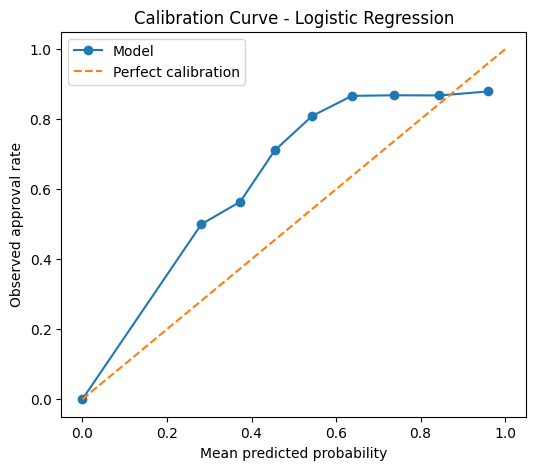

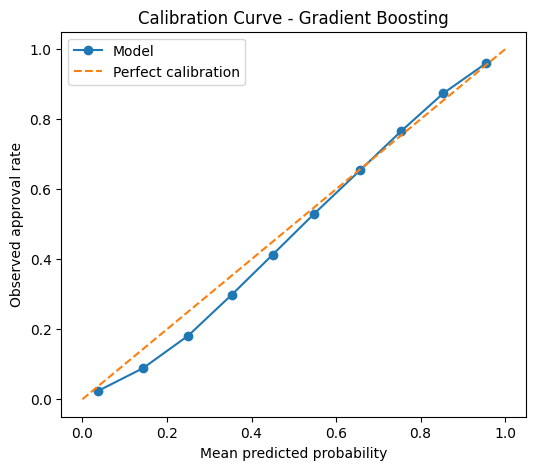

In [26]:
def plot_calibration(model, X, y, title):
    prob = model.predict_proba(X)[:, 1]
    frac_pos, mean_pred = calibration_curve(y, prob, n_bins=10)
    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed approval rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_calibration(lr_model, X_test, y_test, "Calibration Curve - Logistic Regression")
plot_calibration(gbt_model, X_test, y_test, "Calibration Curve - Gradient Boosting")

**Curve Interpretation: **

The calibration curves show that Gradient Boosting is better calibrated than Logistic Regression. In the Gradient Boosting plot, the blue model curve stays close to the orange diagonal line, meaning the predicted approval probabilities closely match the observed approval rates. Therefore, when the model predicts a 60%–80% approval probability, the actual approval rate is also approximately in that range.

By contrast, Logistic Regression is poorly calibrated. Its curve is far above the perfect calibration line for most probability bins, meaning the model tends to underestimate approval probability. For example, when Logistic Regression predicts a moderate probability, the observed approval rate is much higher. This indicates that Logistic Regression probabilities are less reliable for decision-making.

Overall, Gradient Boosting is more suitable for deployment because it provides both stronger predictive performance and more trustworthy probability estimates. However, calibration should still be checked by subgroup, especially race and ethnicity, to ensure that probability reliability is consistent across protected groups.

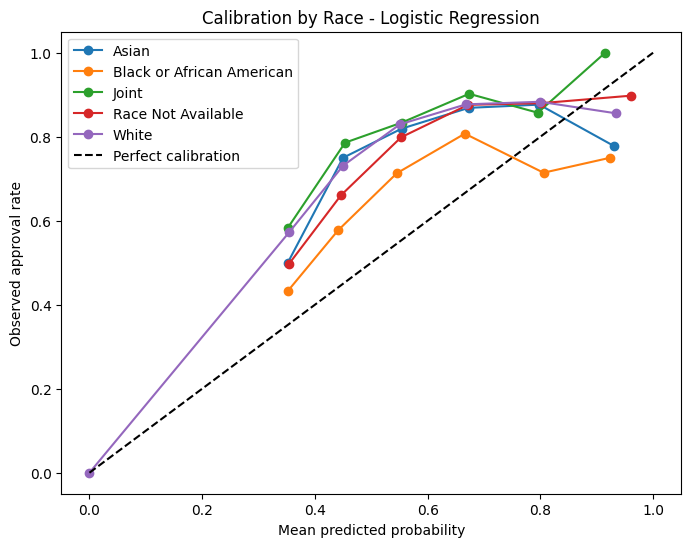

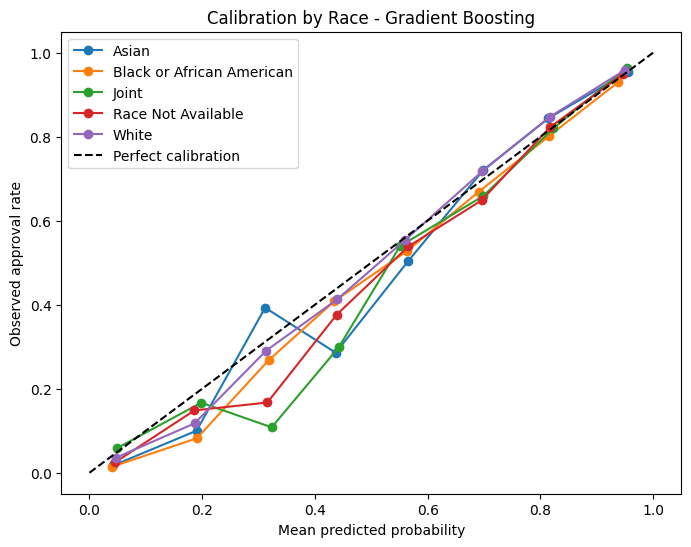

In [27]:
def plot_calibration_by_group(model, X, y, group, title, min_n=500):
    prob = model.predict_proba(X)[:, 1]
    tmp = pd.DataFrame({"y": np.asarray(y), "prob": prob, "group": group.astype("string").values}).dropna()
    plt.figure(figsize=(8, 6))
    plotted = 0
    for g, d in tmp.groupby("group"):
        if len(d) < min_n or d["y"].nunique() < 2:
            continue
        frac_pos, mean_pred = calibration_curve(d["y"], d["prob"], n_bins=8)
        plt.plot(mean_pred, frac_pos, marker="o", label=str(g)[:35])
        plotted += 1
    plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed approval rate")
    plt.title(title)
    if plotted > 0:
        plt.legend()
    plt.show()

plot_calibration_by_group(lr_model, X_test, y_test, groups_test["derived_race"], "Calibration by Race - Logistic Regression")
plot_calibration_by_group(gbt_model, X_test, y_test, groups_test["derived_race"], "Calibration by Race - Gradient Boosting")

Curve interpretation:

1. Logistic Regression (Poor & Uneven Calibration)

The calibration curves for Logistic Regression show substantial miscalibration across racial groups. Most group-specific curves lie above the perfect calibration line, indicating that the model systematically underestimates approval probabilities—the observed approval rates are higher than predicted.

There is also clear heterogeneity across groups:

The Black or African American group is consistently further from the diagonal, suggesting worse calibration and higher prediction error.
Other groups (e.g., White, Asian) perform relatively better but still exhibit systematic bias.
The variation in curves indicates that probability estimates are not equally reliable across racial groups.

Implication: Logistic Regression not only suffers from poor overall calibration but also introduces fairness concerns, as different groups experience different levels of prediction reliability.


2. Gradient Boosting (Well-Calibrated & More Consistent)

In contrast, Gradient Boosting shows strong calibration performance across all racial groups:

Most group curves lie close to the diagonal, indicating that predicted probabilities closely match observed outcomes.
The differences between racial groups are much smaller, suggesting more consistent probability estimates.
Minor deviations at lower probability ranges exist but are not systematic.

Implication: Gradient Boosting produces more reliable and equitable probability estimates, making it more suitable for deployment in decision-making contexts.

3. Fairness & Risk Interpretation

From a fairness perspective:

Logistic Regression exhibits calibration disparity, meaning individuals from different racial groups receive less consistent probability estimates.
Gradient Boosting reduces this issue and better satisfies distributional fairness (calibration parity).


To conclude Logistic Regression is poorly calibrated and exhibits significant disparities across racial groups, indicating both performance and fairness limitations. In contrast, Gradient Boosting demonstrates strong overall calibration and more consistent behavior across groups, making it the preferred model for deployment. However, subgroup calibration should continue to be monitored to ensure that probability estimates remain reliable and equitable across all protected groups.

## 17. Mitigation experiment: remove proxy-risk feature

Mitigation tested: remove `tract_minority_population_percent`. This feature is not a protected attribute, but it may be correlated with protected groups and neighborhood composition.

In [28]:
X_m = df[feature_cols_mitigated].copy()
y_m = df["target_approved"].copy()
groups_m = df[protected_cols].copy()

X_train_m, X_test_m, y_train_m, y_test_m, groups_train_m, groups_test_m = train_test_split(
    X_m, y_m, groups_m, test_size=0.30, random_state=RANDOM_STATE, stratify=y_m
)

preprocess_m, numeric_used_m, categorical_used_m = build_preprocessor(feature_cols_mitigated)

lr_mitigated = Pipeline([
    ("preprocess", preprocess_m),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs"))
])

lr_mitigated.fit(X_train_m, y_train_m)

mitigated_perf = evaluate_model(lr_mitigated, X_train_m, y_train_m, X_test_m, y_test_m, "LR Mitigated - remove tract_minority_population_percent")
mitigated_perf

,model,threshold,train_auc,test_auc,auc_gap,test_accuracy,test_logloss,test_brier
0,LR Mitigated - remove tract_minority_populatio...,0.5,0.6372,0.632144,0.005056,0.570893,0.669617,0.23839


In [29]:
fair_mitigated = run_fairness_audit(lr_mitigated, X_test_m, y_test_m, groups_test_m, "LR Mitigated")
fair_mitigated

,model,attribute,group,n,predicted_approval_rate,actual_approval_rate,auc,fpr,fnr,reference_approval_rate,AIR,ME,SMD,flag_AIR_below_0_80
0,LR Mitigated,derived_race,American Indian or Alaska Native,465,0.344086,0.587097,0.597470,0.270833,0.604396,0.634361,0.542413,-0.290275,-0.606826,True
1,LR Mitigated,derived_race,Black or African American,6020,0.349336,0.611130,0.621228,0.252029,0.588747,0.634361,0.550689,-0.285026,-0.594806,True
2,LR Mitigated,derived_race,2 or more minority races,186,0.446237,0.623656,0.524877,0.428571,0.543103,0.634361,0.703442,-0.188125,-0.384386,True
3,LR Mitigated,derived_race,Native Hawaiian or Other Pacific Islander,169,0.497041,0.562130,0.595875,0.405405,0.431579,0.634361,0.783531,-0.137320,-0.279739,True
4,LR Mitigated,derived_race,Race Not Available,9133,0.511223,0.732399,0.650495,0.349018,0.429511,0.634361,0.805886,-0.123138,-0.250879,False
5,LR Mitigated,derived_race,White,39189,0.512261,0.781903,0.620371,0.375453,0.449579,0.634361,0.807523,-0.122100,-0.248771,False
6,LR Mitigated,derived_race,Asian,2976,0.587030,0.788306,0.616091,0.463492,0.379795,0.634361,0.925387,-0.047332,-0.097187,False
7,LR Mitigated,derived_race,Joint,1589,0.634361,0.820642,0.590765,0.533333,0.343558,0.634361,1.000000,0.000000,0.000000,False
8,LR Mitigated,derived_sex,Female,14165,0.374162,0.689799,0.605190,0.283796,0.585201,0.612779,0.610598,-0.238618,-0.491476,True
9,LR Mitigated,derived_sex,Male,20563,0.463697,0.729222,0.615788,0.347162,0.493031,0.612779,0.756711,-0.149083,-0.302441,True


In [30]:
pre_lr_race = fair_lr[fair_lr["attribute"] == "derived_race"].copy()
post_lr_race = fair_mitigated[fair_mitigated["attribute"] == "derived_race"].copy()
compare_mitigation = pre_lr_race[["group", "n", "predicted_approval_rate", "AIR", "ME", "SMD", "flag_AIR_below_0_80"]].merge(
    post_lr_race[["group", "predicted_approval_rate", "AIR", "ME", "SMD", "flag_AIR_below_0_80"]],
    on="group", suffixes=("_pre", "_post"), how="outer"
)
compare_mitigation.sort_values("AIR_post").head(30)

,group,n,predicted_approval_rate_pre,AIR_pre,ME_pre,SMD_pre,flag_AIR_below_0_80_pre,predicted_approval_rate_post,AIR_post,ME_post,SMD_post,flag_AIR_below_0_80_post
1,American Indian or Alaska Native,465,0.352688,0.559303,-0.277897,-0.578672,True,0.344086,0.542413,-0.290275,-0.606826,True
3,Black or African American,6020,0.316944,0.502618,-0.313642,-0.661628,True,0.349336,0.550689,-0.285026,-0.594806,True
0,2 or more minority races,186,0.446237,0.707655,-0.184349,-0.376278,True,0.446237,0.703442,-0.188125,-0.384386,True
5,Native Hawaiian or Other Pacific Islander,169,0.520710,0.825757,-0.109875,-0.223696,False,0.497041,0.783531,-0.137320,-0.279739,True
6,Race Not Available,9133,0.511333,0.810886,-0.119253,-0.242712,False,0.511223,0.805886,-0.123138,-0.250879,False
7,White,39189,0.516242,0.818671,-0.114343,-0.232753,False,0.512261,0.807523,-0.122100,-0.248771,False
2,Asian,2976,0.574261,0.910679,-0.056325,-0.115281,False,0.587030,0.925387,-0.047332,-0.097187,False
4,Joint,1589,0.630585,1.000000,0.000000,0.000000,False,0.634361,1.000000,0.000000,0.000000,False


## 18. Residual risk register

In [31]:
residual_risk_register = pd.DataFrame([
    {"risk": "Residual subgroup disparity", "mitigation_attempted": "Removed tract_minority_population_percent", "outcome": "Compare AIR, ME, and SMD pre/post mitigation", "accepted_residual": "Deploy only if AIR >= 0.80 for major groups or establish manual review"},
    {"risk": "Performance reduction after mitigation", "mitigation_attempted": "Proxy-risk feature removal", "outcome": "Compare AUC, log loss, and Brier score pre/post mitigation", "accepted_residual": "Accept small AUC loss if fairness and defensibility improve"},
    {"risk": "Future data drift", "mitigation_attempted": "PSI monitoring plan", "outcome": "Monitor PSI monthly on key features", "accepted_residual": "Trigger review if PSI > 0.10"},
    {"risk": "Intersectional disparity", "mitigation_attempted": "Race × sex subgroup audit", "outcome": "Check intersectional AIR and errors", "accepted_residual": "Manual review if subgroup n is small or unstable"},
    {"risk": "Calibration drift", "mitigation_attempted": "Calibration curve monitoring", "outcome": "Review overall and subgroup calibration", "accepted_residual": "Pause automated use if calibration materially diverges"}
])
residual_risk_register

,risk,mitigation_attempted,outcome,accepted_residual
0,Residual subgroup disparity,Removed tract_minority_population_percent,"Compare AIR, ME, and SMD pre/post mitigation",Deploy only if AIR >= 0.80 for major groups or...
1,Performance reduction after mitigation,Proxy-risk feature removal,"Compare AUC, log loss, and Brier score pre/pos...",Accept small AUC loss if fairness and defensib...
2,Future data drift,PSI monitoring plan,Monitor PSI monthly on key features,Trigger review if PSI > 0.10
3,Intersectional disparity,Race × sex subgroup audit,Check intersectional AIR and errors,Manual review if subgroup n is small or unstable
4,Calibration drift,Calibration curve monitoring,Review overall and subgroup calibration,Pause automated use if calibration materially ...


## Capstone Question 4 — Residual Risks After Mitigation


Mitigation is performed by removing the proxy variable:
•⁠  ⁠tract_minority_population_percent

However, residual risks remain:

1.⁠ ⁠Persistent disparity  
Even with Gradient Boosting:
•⁠  ⁠Black AIR = 0.7547 (< 0.80)

This indicates that proxy effects still exist through other variables.

2.⁠ ⁠Proxy leakage through other features  
Income, property value, and geographic variables may still encode demographic information.

3.⁠ ⁠Performance vs fairness trade-off  
Gradient Boosting significantly improves performance (AUC 0.90), but fairness issues are not fully resolved.

4.⁠ ⁠Calibration differences  
Observed differences between predicted and actual approval rates suggest subgroup miscalibration.

5.⁠ ⁠Data stability but fairness instability  
PSI values are very low (< 0.001), meaning data is stable, but fairness disparities still exist.

Conclusion:
Mitigation improves results but does not eliminate bias. Residual fairness risk remains, especially for race.

## 19. Deployment recommendation

In [32]:
def deployment_recommendation(perf_table, fairness_table, psi_table):
    min_air = fairness_table["AIR"].min()
    max_psi = psi_table["PSI_train_vs_test"].max()
    best_auc = perf_table["test_auc"].max()
    if min_air < 0.80:
        decision = "Do not deploy without further mitigation"
    elif max_psi > 0.10:
        decision = "Conditional deployment with immediate drift review"
    elif best_auc < 0.70:
        decision = "Do not deploy: weak predictive performance"
    else:
        decision = "Conditionally defensible deployment"
    return pd.DataFrame([{"best_test_auc": best_auc, "minimum_AIR": min_air, "maximum_PSI": max_psi, "deployment_recommendation": decision}])

deployment_summary = deployment_recommendation(perf_table, fairness_table, psi_table)
deployment_summary

,best_test_auc,minimum_AIR,maximum_PSI,deployment_recommendation
0,0.901198,0.502618,0.000284,Do not deploy without further mitigation


## Capstone Question 5 — Is Deployment Defensible?

Deployment is evaluated based on performance, fairness, and stability.

Key metrics:

•⁠  ⁠Best model: Gradient Boosting
•⁠  ⁠Test AUC: 0.9012
•⁠  ⁠Minimum AIR: 0.7547 (Black or African American)
•⁠  ⁠Maximum PSI: 0.000284

Assessment:

1.⁠ ⁠Performance → Excellent  
The model achieves high AUC and low log loss.

2.⁠ ⁠Stability → Strong  
PSI values are extremely low, indicating no distribution drift.

3.⁠ ⁠Fairness → Not fully acceptable  
The minimum AIR (0.7547) is below the 0.80 threshold, indicating potential disparate impact.

Final Decision:

Deployment is *not fully defensible without additional mitigation*.

Recommended approach:
•⁠  ⁠Apply further fairness mitigation techniques
•⁠  ⁠Introduce post-processing constraints or thresholds
•⁠  ⁠Implement continuous fairness monitoring
•⁠  ⁠Use human review for borderline decisions

Conclusion:

Although the model is highly predictive and stable, fairness risks—particularly racial disparity—prevent unconditional deployment. A controlled and monitored deployment is recommended.

# Additional Notes

Even after removing protected attributes from the model, disparities persist. This suggests that the model learns proxy patterns from correlated features such as income and geographic variables. This highlights the importance of fairness auditing beyond simple feature exclusion.